# Data Preparation & EDA (Exploratory Data Analysis)

### Bibliotecas

In [89]:
import pandas as pd
import numpy as np
import unicodedata
import re
from sklearn.preprocessing import OrdinalEncoder
from datetime import datetime

### Funções para Tratamento de Dados (Dataframes)

In [90]:
# Funções de Tratamento de Dados
def trata_coluna_nome(df: pd.DataFrame, col: str):
  """
  Trata coluna Nome.
  """
  df_processado = df.copy()

  df_processado[col] = df_processado[col].str.upper()
  df_processado[col] = df_processado[col].str.replace('ALUNO-', '', regex=False)

  return df_processado

In [91]:
def codificar_categorias(df: pd.DataFrame, colunas : list):
  """
  Transforma colunas de texto em reais e retorna o df + o encoder.
  """
  df_processado = df.copy()

  encoder = OrdinalEncoder(dtype=float, handle_unknown='use_encoded_value', unknown_value=-1)
  df_processado[colunas] = encoder.fit_transform(df[colunas],)

  return df_processado, encoder

In [92]:
def converte_colunas_para_float(df: pd.DataFrame, colunas: list):
  """
  Converte colunas para float.
  """
  df_processado = df.copy()

  for col in colunas:
      df_processado[col] = df_processado[col].astype(str).str.replace(',', '.', regex=False)
      df_processado[col] = pd.to_numeric(df_processado[col], errors='coerce')

  return df_processado

In [93]:
def preenche_coluna_com_media(df: pd.DataFrame, coluna: list):
  """
  Preenche coluna com a média dos valores não nulos.
  """
  df_processado = df.copy()

  media = round(df_processado[coluna].mean(), 1)
  df_processado[coluna] = df_processado[coluna].fillna(media)

  return df_processado

In [94]:
def padronizar_colunas(df):
    """
    Limpa os nomes das colunas: remove acentos, troca espaços por '_',
    remove caracteres especiais e coloca tudo em MAIÚSCULO.
    """
    def limpar_texto(texto):
        if not isinstance(texto, str):
            return texto
        # Remove acentos
        texto = unicodedata.normalize('NFKD', texto).encode('ASCII', 'ignore').decode('ASCII')
        # Remove caracteres especiais (exceto letras, números e espaços)
        texto = re.sub(r'[^a-zA-Z0-9\s]', '', texto)
        # Troca espaços por underscore e coloca em maiúsculo
        return texto.strip().replace(' ', '_').upper()

    df.columns = [limpar_texto(col) for col in df.columns]

    # Dicionário de De/Para para variações específicas
    mapeamento = {
        'RA': 'RA',
        'NOME_ANONIMIZADO': 'NOME',
        'ANO_NASC': 'DATA_NASCIMENTO',
        'DATA_DE_NASC': 'DATA_NASCIMENTO',
        'IDADE_22': 'IDADE',
        'MATEM': 'MATEMATICA',
        'MAT': 'MATEMATICA',
        'PORTUG': 'PORTUGUES',
        'POR': 'PORTUGUES',
        'INGLES': 'INGLES',
        'ING': 'INGLES',
        'FASE_IDEAL': 'FASE_IDEAL',
        'DEFAS': 'DEFASAGEM',
        'INSTITUICAO_DE_ENSINO': 'INSTITUICAO_ENSINO',
        'N_AV': 'NUM_AVALIACOES',
        'PEDRA_20': 'PEDRA',
        'PEDRA_21': 'PEDRA',
        'PEDRA_22': 'PEDRA',
        'PEDRA_23': 'PEDRA',
        'PEDRA_24': 'PEDRA',
        'PEDRA_2020': 'PEDRA',
        'PEDRA_2021': 'PEDRA',
        'PEDRA_2022': 'PEDRA',
        'PEDRA_2023': 'PEDRA',
        'PEDRA_2024': 'PEDRA',
        'INDE_20': 'INDE',
        'INDE_21': 'INDE',
        'INDE_22': 'INDE',
        'INDE_23': 'INDE',
        'INDE_24': 'INDE',
        'INDE_2020': 'INDE',
        'INDE_2021': 'INDE',
        'INDE_2022': 'INDE',
        'INDE_2023': 'INDE',
        'INDE_2024': 'INDE',
        'DATADOREGISTRO': 'DATA_REGISTRO'
    }

    # Renomeia com base no dicionário (apenas se a coluna existir)
    df = df.rename(columns=mapeamento)

    # Trata duplicatas automáticas do pandas (ex: 'Destaque IPV.1')
    df.columns = [re.sub(r'_\d+$', '', col) if col.endswith(tuple(f'_{i}' for i in range(10))) else col for col in df.columns]

    return df

### Carregamento de Dados

In [95]:
# Carregando a base de Dados Bruta

# Pede2022
df_pede2022 = pd.read_csv('data\pede2022.csv', sep=";", encoding='utf-8-sig')
df_pede2022["data_do_registro"] = datetime(2022, 1, 1)

# Pede2023
df_pede2023 = pd.read_csv('data\pede2023.csv', sep=";", encoding='utf-8-sig')
df_pede2023["data_do_registro"] = datetime(2023, 1, 1)

# Analisando colunas dos Dataframes
df_pede2022.columns, df_pede2023.columns

(Index(['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade 22', 'Gênero',
        'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21',
        'Pedra 22', 'INDE 22', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1',
        'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3',
        'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA',
        'Matem', 'Portug', 'Inglês', 'Indicado', 'Atingiu PV', 'IPV', 'IAN',
        'Fase ideal', 'Defas', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV',
        'data_do_registro'],
       dtype='object'),
 Index(['RA', 'Fase', 'INDE 2023', 'Pedra 2023', 'Turma', 'Nome Anonimizado',
        'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso',
        'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23',
        'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1',
        'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3',
        'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'IPP', 'Rec P

### Tratamento dos Dados Brutos: Pede2022

In [96]:
#  Crio df_pede2022_processado (cópia do df original) para aplicar as transformações/tratamentos
df_pede2022_processado = df_pede2022.copy()

# Excluindo ultima linha (NaN)
df_pede2022_processado = df_pede2022_processado.drop(df_pede2022_processado.index[-1])

# Padronizo os dados do dataframe de acordo com seu ano origem
df_pede2022_processado = df_pede2022_processado.drop(
    columns=['Pedra 20', 'Pedra 21']
)

# Excluo features irrelevantes/dados faltantes
df_pede2022_processado = df_pede2022_processado.drop(
    columns=[
      'Nº Av', 'Avaliador1', 'Rec Av1',
      'Avaliador2', 'Rec Av2', 'Avaliador3',
      'Rec Av3', 'Avaliador4', 'Rec Av4'
    ]
)

# Converto valor colunas em float
colunas = [
  'INDE 22', 'Cg', 'IAA', 'IEG', 'IPS',
  'IDA', 'Matem', 'Portug', 'Inglês', 'IPV', 'IAN'
  ]
for col in colunas:
  df_coluna = converte_colunas_para_float(df_pede2022_processado, [col])
  df_pede2022_processado[col] = df_coluna[col]


# Trato valores faltantes das notas
materias = ['Matem', 'Portug', 'Inglês']
for materia in materias:
  df_pede2022_processado = preenche_coluna_com_media(df_pede2022_processado, materia)

# Verifico se há Colunas com dados faltantes
df_pede2022_processado.loc[:, df_pede2022_processado.isna().any()].isnull().sum()

# Categorizando colunas
colunas_codificar_categorias = [
  'Turma', 'Gênero', 'Instituição de ensino', 'Pedra 22',
  'Rec Psicologia', 'Indicado', 'Atingiu PV', 'Fase ideal',
  'Destaque IEG','Destaque IDA', 'Destaque IPV'
]

df_pede2022_processado, encoder_df_pede2022_processado = codificar_categorias(
  df_pede2022_processado, colunas_codificar_categorias
)

# Trato coluna NOME
df_pede2022_processado = trata_coluna_nome(df_pede2022_processado, 'Nome')

# Padronizo o nome das colunas
df_pede2022_processado = padronizar_colunas(df_pede2022_processado)

# Verifico se há Colunas com dados faltantes
df_pede2022_processado.loc[:, df_pede2022_processado.isna().any()].isnull().sum()

# Verificação de colunas até então
df_pede2022_processado.columns

# exporta df_pede_processado
df_pede2022_processado.to_csv('data\df_pede2022_processado.csv', sep=";", index=False)

# Crio dataframe evasão escolar para Pede2022
df_evasao_escolar = df_pede2022_processado.copy()

# Excluo alunos do ultimo ano
df_evasao_escolar = df_evasao_escolar[df_evasao_escolar['FASE'] < 7]
# df_evasao_escolar.head()

feature_store = df_evasao_escolar.columns.tolist()
#print(sorted(feature_store))
df_evasao_escolar.info()

<class 'pandas.core.frame.DataFrame'>
Index: 839 entries, 21 to 859
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   RA                  839 non-null    object        
 1   FASE                839 non-null    float64       
 2   TURMA               839 non-null    float64       
 3   NOME                839 non-null    object        
 4   DATA_NASCIMENTO     839 non-null    float64       
 5   IDADE               839 non-null    float64       
 6   GENERO              839 non-null    float64       
 7   ANO_INGRESSO        839 non-null    float64       
 8   INSTITUICAO_ENSINO  839 non-null    float64       
 9   PEDRA               839 non-null    float64       
 10  INDE                839 non-null    float64       
 11  CG                  839 non-null    float64       
 12  CF                  839 non-null    float64       
 13  CT                  839 non-null    float64       
 14

### Tratamento dos Dados Brutos: Pede2023

In [63]:
#  Crio df_pede2023_processado (cópia do df original) para aplicar as transformações/tratamentos
df_pede2023_processado = df_pede2023.copy()
df_pede2023_processado = padronizar_colunas(df_pede2023_processado)
df_pede2023_processado = trata_coluna_nome(df_pede2023_processado, 'NOME')
df_pede2023_processado = df_pede2023_processado['NOME']
df_pede2023_processado.head()

# Excluo alunos do ultimo ano
df_evasao_escolar['EVASAO'] = np.where(
    #df_evasao_escolar['NOME'].isin(df_pede2023_processado['NOME']),
    df_evasao_escolar['NOME'].isin(df_pede2023_processado),
    0,
    1
)

# Quantos evadidos?
df_evasao_escolar['EVASAO'].value_counts()

# exporta df_pede_processado
df_evasao_escolar.to_csv('data\df_evasao_escolar.csv', sep=";", index=False)
df_evasao_escolar.to_parquet('data\df_evasao_escolar.parquet')

### EDA (Exploratory Data Analysis) e Preparação de Dados para FeatureStore

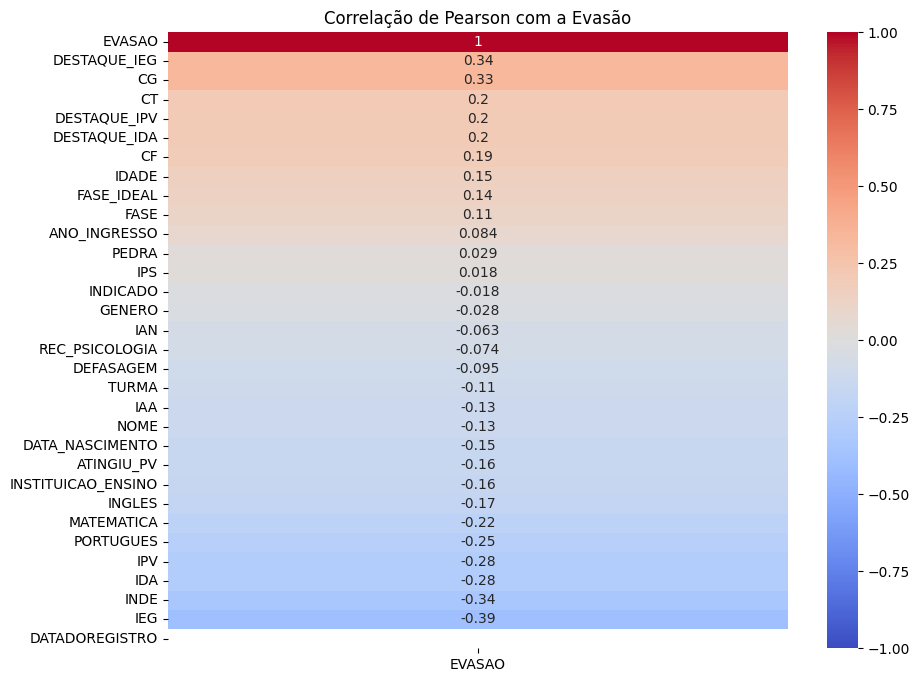

Correlação Point-Biserial (Numéricas vs EVASAO):
FASE: Corr=0.1134, p-value=0.0010
TURMA: Corr=-0.1093, p-value=0.0015
DATA_NASCIMENTO: Corr=-0.1495, p-value=0.0000
IDADE: Corr=0.1495, p-value=0.0000
GENERO: Corr=-0.0282, p-value=0.4145
ANO_INGRESSO: Corr=0.0840, p-value=0.0150
INSTITUICAO_ENSINO: Corr=-0.1619, p-value=0.0000
PEDRA: Corr=0.0294, p-value=0.3947
INDE: Corr=-0.3419, p-value=0.0000
CG: Corr=0.3285, p-value=0.0000
CF: Corr=0.1884, p-value=0.0000
CT: Corr=0.2040, p-value=0.0000
IAA: Corr=-0.1268, p-value=0.0002
IEG: Corr=-0.3932, p-value=0.0000
IPS: Corr=0.0184, p-value=0.5944
REC_PSICOLOGIA: Corr=-0.0737, p-value=0.0328
IDA: Corr=-0.2846, p-value=0.0000
MATEMATICA: Corr=-0.2245, p-value=0.0000
PORTUGUES: Corr=-0.2512, p-value=0.0000
INGLES: Corr=-0.1749, p-value=0.0000
INDICADO: Corr=-0.0184, p-value=0.5952
ATINGIU_PV: Corr=-0.1561, p-value=0.0000
IPV: Corr=-0.2807, p-value=0.0000
IAN: Corr=-0.0627, p-value=0.0696
FASE_IDEAL: Corr=0.1449, p-value=0.0000
DEFASAGEM: Corr=-0.0

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Carregar dados (ler feature store ou S3)
df = pd.read_parquet('data\df_evasao_escolar.parquet')

# --- 1. Correlação Linear (Pearson) ---
# Útil para uma visão geral rápida de todas as variáveis numéricas
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix[['EVASAO']].sort_values(by='EVASAO', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlação de Pearson com a Evasão")
plt.show()

# --- 2. Point-Biserial para variáveis específicas ---
# Exemplo: Correlação entre 'Faltas' e 'Evasão'
# (Substitua 'Faltas' pelo nome real da sua coluna numérica)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('EVASAO')

print("Correlação Point-Biserial (Numéricas vs EVASAO):")
for col in num_cols:
    pb_corr, p_value = stats.pointbiserialr(df[col], df['EVASAO'])
    print(f"{col}: Corr={pb_corr:.4f}, p-value={p_value:.4f}")

# --- 3. Importância via Random Forest (A mais robusta) ---
# Como vimos no script anterior, modelos de árvore capturam correlações não-lineares
# que o Pearson as vezes ignora.